In [ ]:
"""
HEART DISEASE DATASET
=====================

Features:
age     : Age in years
sex     : 1=Male, 0=Female
cp      : Chest pain (1=Typical, 2=Atypical, 3=Non-anginal, 4=Asymptomatic)
trestbps: Resting BP (mm Hg)
chol    : Serum cholesterol (mg/dl)
fbs     : Fasting BS >120 (1=Yes, 0=No)
restecg : Resting ECG (0=Normal, 1=ST-T abnormality, 2=LV hypertrophy)
thalach : Max heart rate achieved
exang   : Exercise induced angina (1=Yes, 0=No)
oldpeak : ST depression
slope   : ST segment slope (1=Upsloping, 2=Flat, 3=Downsloping)
ca      : Major vessels (0-3)
thal    : Thalassemia (0=Normal, 1=Fixed defect, 2=Reversible defect)
target  : Diagnosis (0=No disease, 1=Disease)

Columns: age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
"""

'\nHEART DISEASE DATASET\n=====================\n\nFeatures:\nage     : Age in years\nsex     : 1=Male, 0=Female\ncp      : Chest pain (1=Typical, 2=Atypical, 3=Non-anginal, 4=Asymptomatic)\ntrestbps: Resting BP (mm Hg)\nchol    : Serum cholesterol (mg/dl)\nfbs     : Fasting BS >120 (1=Yes, 0=No)\nrestecg : Resting ECG (0=Normal, 1=ST-T abnormality, 2=LV hypertrophy)\nthalach : Max heart rate achieved\nexang   : Exercise induced angina (1=Yes, 0=No)\noldpeak : ST depression\nslope   : ST segment slope (1=Upsloping, 2=Flat, 3=Downsloping)\nca      : Major vessels (0-3)\nthal    : Thalassemia (0=Normal, 1=Fixed defect, 2=Reversible defect)\ntarget  : Diagnosis (0=No disease, 1=Disease)\n\nColumns: age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target\n'

In [ ]:
!pip install fg-data-profiling
# Loading dataset
import numpy as np
import pandas as pd

# Model selection and ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

# data modeling
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# EDA
from collections import Counter
from data_profiling import ProfileReport   # Latest package

# data preprocessing
from sklearn.preprocessing import StandardScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.3/400.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.2 MB/s eta 0:00:00


In [ ]:
data = pd.read_csv('/content/heart disease kaggle.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
data.shape

(1025, 14)

In [ ]:
# Generate the profile report
profile = ProfileReport(data, title="Heart Disease Dataset Profile Report")
# Save the report to an HTML file
profile.to_file("heart_disease_profile_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 34.83it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# checking for missing val
data.isnull().sum()
# duplicate
data.duplicated().sum()

np.int64(723)

In [ ]:
# statistical measure
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
data['target'].value_counts()

,count
target,
1,526
0,499


In [ ]:
# droping a col---> axis = 1 ; row ---> axis = 0
Y = data['target']
X = data.drop(columns='target',axis=1)

In [ ]:
# Original data: 70% Disease (1), 30% No Disease (0)
#Without stratify: Train might get 90% Disease, Test gets 50% Disease ❌
#With stratify:    Both Train and Test get 70% Disease, 30% No Disease ✅
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)

In [ ]:
print(X.shape,X_train.shape,X_test.shape)
print(Y.shape,Y_train.shape,Y_test.shape)

(1025, 13) (820, 13) (205, 13)
(1025,) (820,) (205,)


In [ ]:
# Check if stratification worked
print("Original:", Y.value_counts(normalize=True))
print("Train:", Y_train.value_counts(normalize=True))
print("Test:", Y_test.value_counts(normalize=True))

Original: target
1    0.513171
0    0.486829
Name: proportion, dtype: float64
Train: target
1    0.513415
0    0.486585
Name: proportion, dtype: float64
Test: target
1    0.512195
0    0.487805
Name: proportion, dtype: float64


In [ ]:
print(Y_test.unique(),Y_train.unique())
Counter(Y_train)

[0 1] [0 1]


Counter({0: 399, 1: 421})

In [ ]:
# Create scaler
scaler = StandardScaler()

# Learn from training data and scale it
X_train = scaler.fit_transform(X_train)

# Scale test data using the same learned parameters
X_test = scaler.transform(X_test)

# **Logistic Regression**

In [ ]:
m1 = LogisticRegression()
m1.fit(X_train,Y_train)
m1_predict_test = m1.predict(X_test)
m1_cm = confusion_matrix(Y_test,m1_predict_test)
print("confussion matrix\n" , m1_cm)
m1_accuracy_Score_test_Data = accuracy_score(Y_test ,m1_predict_test)
print("Accuracy Score on test data : " , m1_accuracy_Score_test_Data*100)
m1_predict_train = m1.predict(X_train) # Predict on training data
# Use predictions on training data
m1_accuracy_Score_train_Data = accuracy_score(Y_train ,m1_predict_train)
print("Accuracy Score on train data : " , m1_accuracy_Score_train_Data*100)
from sklearn.metrics import classification_report

print(classification_report(Y_test, m1_predict_test, target_names=['No Disease', 'Disease']))

confussion matrix
 [[73 27]
 [13 92]]
Accuracy Score on test data :  80.48780487804879
Accuracy Score on train data :  85.85365853658537
              precision    recall  f1-score   support

  No Disease       0.85      0.73      0.78       100
     Disease       0.77      0.88      0.82       105

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



# **Naive Bayes**

In [ ]:
m2 = GaussianNB()
m2.fit(X_train,Y_train)
m2_predict_test = m2.predict(X_test)
m2_cm = confusion_matrix(Y_test,m2_predict_test)
print("confussion matrix\n",m2_cm )
# Use predictions on test data
m2_accuracy_Score_test_Data = accuracy_score(Y_test ,m2_predict_test)
print("Accuracy Score on test data : " , m2_accuracy_Score_test_Data*100)
m2_predict_train = m2.predict(X_train) # Predict on training data
# Use predictions on training data
m2_accuracy_Score_train_Data = accuracy_score(Y_train ,m2_predict_train)
print("Accuracy Score on train data : " , m2_accuracy_Score_train_Data*100)
print(classification_report(Y_test, m2_predict_test, target_names=['No Disease', 'Disease']))

confussion matrix
 [[75 25]
 [20 85]]
Accuracy Score on test data :  78.04878048780488
Accuracy Score on train data :  83.90243902439025
              precision    recall  f1-score   support

  No Disease       0.79      0.75      0.77       100
     Disease       0.77      0.81      0.79       105

    accuracy                           0.78       205
   macro avg       0.78      0.78      0.78       205
weighted avg       0.78      0.78      0.78       205



# **Random Forest Classfier**

In [ ]:
m3 = rf = RandomForestClassifier(
    n_estimators=20,    # 20 trees
    random_state=12,     # Reproducible
    max_depth=5          # Limit tree depth
)
m3.fit(X_train , Y_train)
m3_predict_test = m3.predict(X_test)
m3_cm = confusion_matrix(Y_test,m3_predict_test)
print("confussion matrix\n" , m3_cm)
m3_accuracy_Score_test_Data = accuracy_score(Y_test ,m3_predict_test)
print("Accuracy Score on test data : " , m3_accuracy_Score_test_Data*100)
# Use predictions on training data
m3_predict_train = m3.predict(X_train) # Predict on training data
m3_accuracy_Score_train_Data = accuracy_score(Y_train ,m3_predict_train)
print("Accuracy Score on train data : " , m3_accuracy_Score_train_Data*100)
print(classification_report(Y_test, m3_predict_test, target_names=['No Disease', 'Disease']))

confussion matrix
 [[87 13]
 [12 93]]
Accuracy Score on test data :  87.8048780487805
Accuracy Score on train data :  93.53658536585367
              precision    recall  f1-score   support

  No Disease       0.88      0.87      0.87       100
     Disease       0.88      0.89      0.88       105

    accuracy                           0.88       205
   macro avg       0.88      0.88      0.88       205
weighted avg       0.88      0.88      0.88       205



#**Decision Tree Classifier**

In [ ]:
m4 = DecisionTreeClassifier(criterion = 'entropy',random_state=0,max_depth = 6)
m4.fit(X_train, Y_train)
#test data
m4_predict_test = m4.predict(X_test)
print("Accuracy Score on test data : " , accuracy_score(Y_test ,m4_predict_test)*100)
#train data
m4_predict_train = m4.predict(X_train)
print("Accuracy Score on train data : " , accuracy_score(Y_train ,m4_predict_train)*100)
# confusion matrix
m4_cm = confusion_matrix(Y_test,m4_predict_test)
print("confussion matrix\n" , m4_cm)

Accuracy Score on test data :  92.6829268292683
Accuracy Score on train data :  95.60975609756098
confussion matrix
 [[93  7]
 [ 8 97]]


# **Support Vector Classifier** **bold text**

In [ ]:
m5 = SVC(kernel='rbf', C=2) #C = Cost (or Penalty) for misclassifying training examples.

m5.fit(X_train, Y_train)
#test data
m5_predict_test = m5.predict(X_test)
print("Accuracy Score on test data : " , accuracy_score(Y_test ,m5_predict_test)*100)
#training data
m5_predict_train = m5.predict(X_train)
print("Accuracy Score on train data : " , accuracy_score(Y_train ,m5_predict_train)*100)
#confusion matrix
m5_cm = confusion_matrix(Y_test,m5_predict_test)
print("confussion matrix\n" , m5_cm)

Accuracy Score on test data :  95.1219512195122
Accuracy Score on train data :  97.07317073170731
confussion matrix
 [[96  4]
 [ 6 99]]


# **Extreme Gradient Boost**

In [ ]:
m6 = xgb = XGBClassifier(
     learning_rate=0.01,      # Step size shrinkage (lower = more accurate, needs more trees)
    n_estimators=25,         # Number of boosting rounds (trees in ensemble)
    max_depth=15,            # Maximum tree depth (higher = more complex patterns)

    # Regularization parameters (prevent overfitting)
    gamma=0.6,               # Minimum loss reduction for split (higher = fewer splits)
    subsample=0.52,          # % of training data used per tree (adds randomness)
    colsample_bytree=0.6,    # % of features used per tree (forces diversity)
    colsample_bylevel=0.6,   # % of features used per level/split
    colsample_bynode=0.5,    # % of features used per node (fine-grained sampling)
    reg_lambda=2,            # L2 regularization (penalizes complex models)

    # Booster settings
    booster='dart',          # DART = Dropouts meet Multiple Additive Regression Trees

    # Reproducibility
    seed=27                  # Random seed for reproducible results

)
m6.fit(X_train, Y_train)
#test

m6_predict_test = m6.predict(X_test)
print("Accuracy Score on test data : " , accuracy_score(Y_test ,m6_predict_test)*100)
#training
m6_predict_train = m6.predict(X_train)
print("Accuracy Score on train data : " , accuracy_score(Y_train ,m6_predict_train)*100)
#cm
m6_cm = confusion_matrix(Y_test,m6_predict_test)
print("confussion matrix\n" , m6_cm)

Accuracy Score on test data :  85.36585365853658
Accuracy Score on train data :  89.02439024390245
confussion matrix
 [[ 74  26]
 [  4 101]]


# **K-Nearest Neighbors Classifier**

In [ ]:
m7_knn = KNeighborsClassifier(n_neighbors=5)
m7_knn.fit(X_train, Y_train)

m7_knn_predict_test = m7_knn.predict(X_test)
m7_knn_cm = confusion_matrix(Y_test, m7_knn_predict_test)
print("Confusion matrix\n", m7_knn_cm)

m7_knn_accuracy_Score_test_Data = accuracy_score(Y_test, m7_knn_predict_test)
print("Accuracy Score on test data : ", m7_knn_accuracy_Score_test_Data * 100)

m7_knn_predict_train = m7_knn.predict(X_train)
m7_knn_accuracy_Score_train_Data = accuracy_score(Y_train, m7_knn_predict_train)
print("Accuracy Score on train data : ", m7_knn_accuracy_Score_train_Data * 100)

print(classification_report(Y_test, m7_knn_predict_test, target_names=['No Disease', 'Disease']))

Confusion matrix
 [[90 10]
 [19 86]]
Accuracy Score on test data :  85.85365853658537
Accuracy Score on train data :  95.48780487804878
              precision    recall  f1-score   support

  No Disease       0.83      0.90      0.86       100
     Disease       0.90      0.82      0.86       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



#**model evaluation**

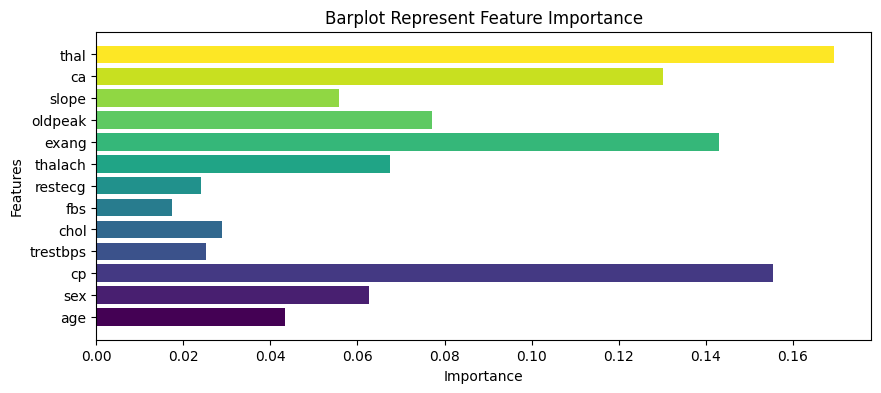

In [ ]:
imp_feature = pd.DataFrame({
    'Feature': ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach','exang', 'oldpeak', 'slope', 'ca', 'thal'],
    'Importance': xgb.feature_importances_
})

plt.figure(figsize=(10, 4))
plt.title("Barplot Represent Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

# Use a colormap - automatically gives different colors
colors = plt.cm.viridis(np.linspace(0, 1, len(imp_feature)))

plt.barh(imp_feature['Feature'], imp_feature['Importance'], color=colors)
plt.show()

In [51]:
model_ev = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Decision Tree',
        'Random Forest',
        'Support Vector Machine',
        'K-Nearest Neighbors',
        'XGBoost'
    ],
    'Accuracy (%)': [
        m1_accuracy_Score_test_Data * 100,
        m2_accuracy_Score_test_Data * 100,
        accuracy_score(Y_test, m4_predict_test) * 100,
        m3_accuracy_Score_test_Data * 100,
        accuracy_score(Y_test, m5_predict_test) * 100,
        m7_knn_accuracy_Score_test_Data * 100,
        accuracy_score(Y_test, m6_predict_test) * 100
    ]
})

# Sort by accuracy
model_ev = model_ev.sort_values(by='Accuracy (%)', ascending=False)

print("MODEL ACCURACY COMPARISON")
print("=" * 60)
print(model_ev.to_string(index=False))

# Best model
best = model_ev.iloc[0]

print("\n BEST MODEL")
print(f"Model    : {best['Model']}")
print(f"Accuracy : {best['Accuracy (%)']:.2f}%")

MODEL ACCURACY COMPARISON
                 Model  Accuracy (%)
Support Vector Machine     95.121951
         Decision Tree     92.682927
         Random Forest     87.804878
   K-Nearest Neighbors     85.853659
               XGBoost     85.365854
   Logistic Regression     80.487805
           Naive Bayes     78.048780

 BEST MODEL
Model    : Support Vector Machine
Accuracy : 95.12%


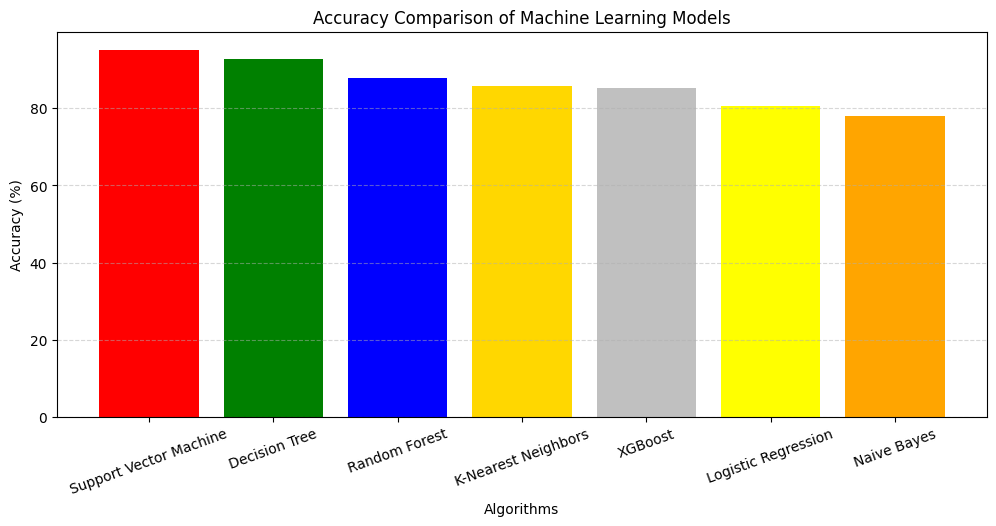

In [ ]:
colors = ['red', 'green', 'blue', 'gold', 'silver', 'yellow', 'orange']

plt.figure(figsize=(12, 5))

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy (%)")

plt.bar(model_ev['Model'], model_ev['Accuracy (%)'], color=colors)

plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [54]:
print("QUICK OVERFITTING CHECK\n\n")

# Calculate gaps for all models
models_info = [
    ('Logistic Regression', m1_accuracy_Score_train_Data*100, m1_accuracy_Score_test_Data*100),
    ('Naive Bayes', m2_accuracy_Score_train_Data*100, m2_accuracy_Score_test_Data*100),
    ('Decision Tree', accuracy_score(Y_train, m4_predict_train)*100, accuracy_score(Y_test, m4_predict_test)*100),
    ('SVM', accuracy_score(Y_train, m5_predict_train)*100, accuracy_score(Y_test, m5_predict_test)*100),
    ('XGBoost', accuracy_score(Y_train, m6_predict_train)*100, accuracy_score(Y_test, m6_predict_test)*100),
    ('KNN', m7_knn_accuracy_Score_train_Data*100, m7_knn_accuracy_Score_test_Data*100)
]

for name, train_acc, test_acc in models_info:
    gap = train_acc - test_acc
    status = "✅" if gap < 2 else "⚠️" if gap < 5 else "❌"
    print(f"{status} {name:25s} Train: {train_acc:.2f}% | Test: {test_acc:.2f}% | Gap: {gap:.2f}%")

QUICK OVERFITTING CHECK


❌ Logistic Regression       Train: 85.85% | Test: 80.49% | Gap: 5.37%
❌ Naive Bayes               Train: 83.90% | Test: 78.05% | Gap: 5.85%
⚠️ Decision Tree             Train: 95.61% | Test: 92.68% | Gap: 2.93%
✅ SVM                       Train: 97.07% | Test: 95.12% | Gap: 1.95%
⚠️ XGBoost                   Train: 89.02% | Test: 85.37% | Gap: 3.66%
❌ KNN                       Train: 95.49% | Test: 85.85% | Gap: 9.63%
